#**Synthesizing Hand-written Digits with a GAN**

We are going to train a generative adversarial network that can produce synthetic hand-written digits. The network will be trained using the MNIST dataset, and will learn to produce new digit photos based on an input class label!

#*Data and Library Imports*

In [1]:
import tensorflow
from tensorflow.keras.datasets.mnist import load_data
import random
import numpy as np

(trainX,trainY), (testX,testY) = load_data()

11490434/11490434 [==============================] - 0s 0us/step


#*Define our Discriminator*

In [ ]:
from keras.layers import Input, Embedding, Dense, Reshape, Concatenate, LeakyReLU, Flatten, Dropout, Conv2D, Conv2DTranspose
from keras import Model
from keras.utils import plot_model

# define standalone discriminator
def define_discriminator(input_shape=(28,28,1),n_classes=10):
  # label input
  in_labels = Input(shape=(1,))
  # Embedding for categorical input
  em = Embedding(n_classes,50)(in_labels)
  # scale up the image dimension with linear activations
  d1 = Dense(input_shape[0] * input_shape[1])(em)
  # reshape to additional channel
  d1 = Reshape((input_shape[0],input_shape[1],1))(d1)
  # image input
  image_input = Input(shape=input_shape)
  #  concate label as channel
  merge = Concatenate()([image_input,d1])
  # downsample
  fe = Conv2D(128,(3,3),strides=(2,2),padding='same')(merge)
  fe = LeakyReLU(0.2)(fe)
  # downsample
  fe = Conv2D(128,(3,3),strides=(2,2),padding='same')(fe)
  fe = LeakyReLU(0.2)(fe)
  #flatten feature maps
  fe = Flatten()(fe)
  fe = Dropout(0.4)(fe)
  #ouput
  out_layer = Dense(1,activation='sigmoid')(fe)
  #define model
  model = Model([image_input,in_labels],out_layer)
  #compile model
  model.compile(loss='binary_crossentropy',optimizer="adam",metrics=  ['accuracy'])
  return model

discriminator = define_discriminator()
plot_model(discriminator, show_shapes=True)

#*Define Generator Model*

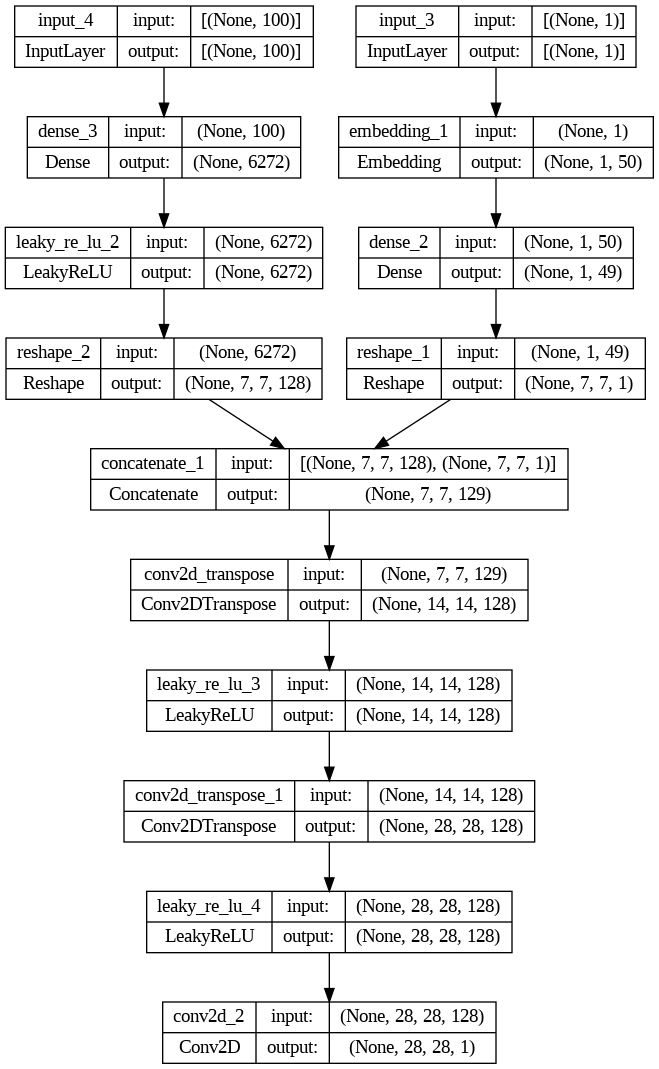

In [4]:
# define standalone generator model
def define_generator(latent_dim=100,n_classes=10):
  label_input = Input(shape=(1,))
  
  #Embedding layer
  em = Embedding(n_classes,50)(label_input)
  nodes = 7*7 # We are going to upsample from a 7x7 image to a 28x28 image at the end.
  em = Dense(nodes)(em)
  em = Reshape((7,7,1))(em)

  #image generator input
  image_input = Input(shape=(latent_dim,))
  nodes = 128*7*7 # The 128 here is the number of feature maps / channels.
  d1 = Dense(nodes)(image_input)
  d1 = LeakyReLU(0.2)(d1)
  d1 = Reshape((7,7,128))(d1)

  # merge
  merge = Concatenate()([d1,em])
  #upsample to 14x14
  gen = Conv2DTranspose(128,(4,4),strides=(2,2),padding='same')(merge)
  gen = LeakyReLU(0.2)(gen)
  #upsample to 28x28
  gen = Conv2DTranspose(128,(4,4),strides=(2,2),padding='same')(gen)
  gen = LeakyReLU(0.2)(gen)
  #output layer taking us down to 1 channel (grayscale) output.
  out_layer = Conv2D(1,(7,7),activation='tanh',padding='same')(gen)
  #define model 
  model = Model([image_input,label_input],out_layer)
  return model

generator = define_generator()
plot_model(generator, show_shapes=True)

#*Finally, wrap the two networks to create our GAN structure*

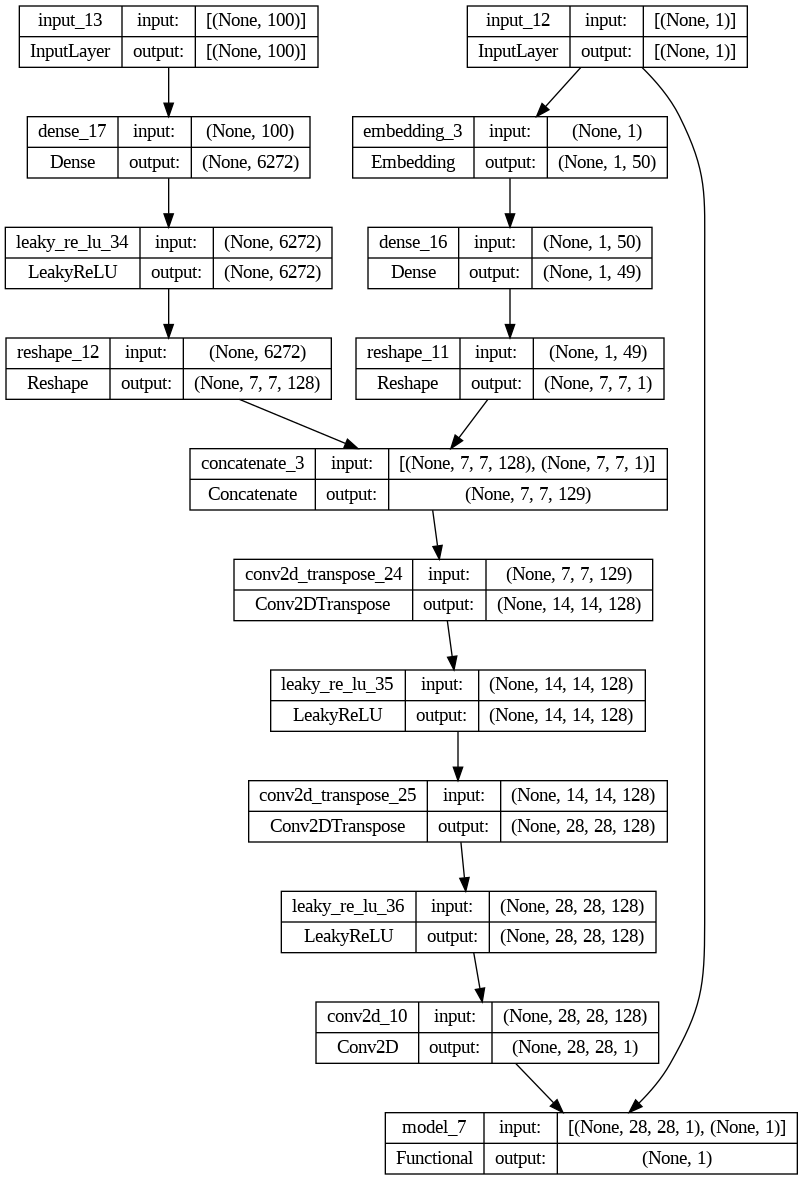

In [ ]:
# defining the combined generator and discriminator model for updating the generator
def define_gan(g_model,d_model):
  # make the discriminator layer as non trainable
  d_model.trainable = False
  # get the noise and label input from the generator
  gen_noise, gen_label = g_model.input
  # get the output from the generator
  gen_output = g_model.output
  #connect image output and label input from generator as inputs to discriminator
  gan_output = d_model([gen_output,gen_label])
  #define gan model as taking noise and label and outputting a #classification
  model = Model([gen_noise,gen_label],gan_output)
  model.compile(loss='binary_crossentropy',optimizer="adam")
  return model

GAN = define_gan(generator,discriminator)
plot_model(GAN, show_shapes=True)

#*Helper Functions for Training*

In [ ]:
from random import randint
import numpy as np

# load mnist images
def load_real_samples():
  (trainX,trainY),(testX,testY) = load_data()
  # expand to 3d
  X = np.expand_dims(trainX,axis=-1)
  #make it float
  X = X.astype('float32')
  # scale from [0,255] to [-1,1]
  X = (X - 127.5) / 127.5
  return [X,trainY]

# select real samples
def generate_real_samples(dataset,n_samples):
  # split into images and labels
  images,labels = dataset
  #choose random instances
  ix = np.random.randint(0,images.shape[0],n_samples)
  # select images and labels
  X, Labels = images[ix], labels[ix]
  # generate class labels
  y = np.ones((n_samples,1))
  return [X,Labels], y

# draw a random noise vector for the generator
def sample_noise(latent_dim,n_samples,n_classes=10):
  # generate points in the latent space
  x_input = np.random.randn(latent_dim*n_samples)
  # reshape into a batch of inputs to the network
  z_input = x_input.reshape(n_samples,latent_dim)
  # generate labels
  labels = np.random.randint(0,n_classes,n_samples)
  return [z_input,labels]

# use generator to generate n fake samples, with class labels
def generate_fake_samples(latent_dim,n_samples,generator):
  #generate points in latent space
  z_input,labels = sample_noise(latent_dim,n_samples)
  #predict outputs
  images = generator.predict([z_input,labels])
  # create class labels
  y = np.zeros((n_samples,1))
  return [np.array(images),labels],y

#*Let's Try It Out!!*

In [ ]:
def train_gan(gen_model,disc_model,gan_model,latent_dim,dataset,n_epochs=50,n_batches=128):
  batches_per_epoch = int(dataset[0].shape[0]/n_batches)
  half_batch = int(n_batches/2)
  for i in range(n_epochs):
    print('epoch ',i)
    for j in range(batches_per_epoch):
      print('batch ',j)
    
      #generate real samples
      [X_real,labels_real], y_real = generate_real_samples(dataset,half_batch)
      #generate fake samples
      [X_fake,labels_fake], y_fake = generate_fake_samples(latent_dim,half_batch,gen_model)
      # train the discriminator on real and fake samples
      loss_real,acc_real = disc_model.train_on_batch([X_real,labels_real],y_real)
      loss_fake,acc_fake = disc_model.train_on_batch([X_fake,labels_fake],y_fake)
      # prepare points in the latent space as input to the generator
      [z_input,labels_input] = sample_noise(latent_dim,n_batches)
      # create inverted labels for fake samples
      y_gan = np.ones((n_batches,1))
      #update the generator model via the discriminator
      g_loss = gan_model.train_on_batch([z_input,labels_input],y_gan)
    if ((i+1)%10) == 0:
      gen_model.save('c_gan%3d.h5'%i)

# size of the noise vector the generator works off of
latent_dim = 100

#dataset is the original MNIST data
dataset = load_real_samples()

#train model
train_gan(generator,discriminator,GAN,latent_dim,dataset)

Generate a synthetic digit image with our trained generator.

In [ ]:
import matplotlib.pyplot as plt

x_input = np.random.randn(latent_dim)
z_input = x_input.reshape(1,latent_dim)

label_input = np.random.randint(0,10,1)
print(label_input)
  
synthetic_img = generator.predict([z_input,label_input])

print(synthetic_img[0])
plt.imshow(synthetic_img[0])